# TAHAP 2 — Exploratory Data Analysis & Preprocessing

Eksplorasi data sintetis yang sudah di-generate di Tahap 1, lalu cleaning dan persiapan data bersih.

**Input:** `data/raw/synthetic_transactions.csv`
**Output:** `data/processed/transactions_cleaned.csv`

**Alur:**
1. Load & overview data
2. Cek missing values & duplikat
3. Visualisasi distribusi severity, amount, waktu
4. Data cleaning & validasi
5. Simpan data bersih

## Import & Load Data

In [21]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Path relatif dari folder notebooks/
RAW_CSV     = os.path.join("..", "data", "raw", "synthetic_transactions.csv")
OUTPUT_DIR  = os.path.join("..", "data", "processed")
OUTPUT_CSV  = os.path.join(OUTPUT_DIR, "transactions_cleaned.csv")

# Load data
df = pd.read_csv(RAW_CSV, parse_dates=["timestamp"])

print(f"[OK] Data loaded: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"     Kolom: {list(df.columns)}")

[OK] Data loaded: 2,900 baris x 8 kolom
     Kolom: ['id', 'cashier_id', 'timestamp', 'transaction_type', 'amount', 'is_synced', 'fraud_severity', 'fraud_profile']


## Overview Data

In [22]:
print("[1/5] Overview Data")
print()
df.info()
print()
df.describe()

[1/5] Overview Data

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                2900 non-null   str           
 1   cashier_id        2900 non-null   str           
 2   timestamp         2900 non-null   datetime64[us]
 3   transaction_type  2900 non-null   str           
 4   amount            2900 non-null   float64       
 5   is_synced         2900 non-null   int64         
 6   fraud_severity    2900 non-null   str           
 7   fraud_profile     2900 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 181.4 KB



,timestamp,amount,is_synced
count,2900,2.900000e+03,2900.0
mean,2026-05-17 05:48:55.348965,1.500621e+05,1.0
min,2026-05-01 16:15:04,2.827300e+03,1.0
25%,2026-05-09 18:07:28.750000,6.898924e+04,1.0
50%,2026-05-17 22:15:09.500000,1.264603e+05,1.0
75%,2026-05-24 22:17:03.500000,1.923897e+05,1.0
max,2026-05-31 04:50:16,1.901334e+06,1.0
std,NaN,1.715850e+05,0.0


In [23]:
# Lihat beberapa baris pertama
df.head(10)

,id,cashier_id,timestamp,transaction_type,amount,is_synced,fraud_severity,fraud_profile
0,508b2c12-355e-4c9b-abf8-cc5e5beb6ef6,CSH-004,2026-05-01 16:15:04,SALE,129224.91,1,LOW,normal
1,eb9f2b1b-3459-4262-9add-d7f2d3514c04,CSH-001,2026-05-01 16:22:24,SALE,250139.48,1,LOW,normal
2,15b7d7a7-9cef-497b-89cf-cd6f062c8351,CSH-002,2026-05-01 16:30:30,SALE,208190.91,1,LOW,normal
3,915f81a5-e235-4d9f-8afa-a0a0c806a1f9,CSH-003,2026-05-01 16:31:27,SALE,201931.50,1,LOW,normal
4,33e1a43d-b11b-4d2e-9a66-f6a9b15b34d5,CSH-004,2026-05-01 16:46:28,SALE,134395.88,1,LOW,normal
5,1e43e0d4-4443-494f-92dc-4cf9a68eca19,CSH-003,2026-05-01 16:52:35,SALE,95839.99,1,LOW,normal
6,e8118599-915c-4c36-9a7b-3d30a59c9ff2,CSH-005,2026-05-01 16:56:39,SALE,26143.01,1,LOW,normal
7,79a4399c-acd7-41e6-b2c7-0c87a484e306,CSH-005,2026-05-01 16:59:44,SALE,7139.93,1,LOW,normal
8,19304dcf-aa6e-47f6-beb1-d5fda4898a44,CSH-005,2026-05-01 17:02:13,SALE,245664.36,1,LOW,normal
9,f4f3a317-c2a1-4897-a3f9-0c0143ff8059,CSH-004,2026-05-01 17:06:42,SALE,178295.05,1,LOW,normal


## Cek Missing Values & Duplikat

In [24]:
print("[2/5] Cek kualitas data")

# Missing values
missing = df.isnull().sum()
print("\n  Missing values per kolom:")
for col, cnt in missing.items():
    status = "OK" if cnt == 0 else f"!! {cnt} missing"
    print(f"    {col:25s}: {status}")

# Duplikat berdasarkan ID
n_dup = df["id"].duplicated().sum()
print(f"\n  Duplikat ID: {n_dup}")

# Validasi tipe data
print(f"\n  Tipe data:")
for col, dtype in df.dtypes.items():
    print(f"    {col:25s}: {dtype}")

# Cek nilai amount yang aneh
neg_amount = (df["amount"] < 0).sum()
zero_amount = (df["amount"] == 0).sum()
print(f"\n  Amount negatif: {neg_amount}")
print(f"  Amount nol: {zero_amount}")

[2/5] Cek kualitas data

  Missing values per kolom:
    id                       : OK
    cashier_id               : OK
    timestamp                : OK
    transaction_type         : OK
    amount                   : OK
    is_synced                : OK
    fraud_severity           : OK
    fraud_profile            : OK

  Duplikat ID: 0

  Tipe data:
    id                       : str
    cashier_id               : str
    timestamp                : datetime64[us]
    transaction_type         : str
    amount                   : float64
    is_synced                : int64
    fraud_severity           : str
    fraud_profile            : str

  Amount negatif: 0
  Amount nol: 0


## Visualisasi: Distribusi Fraud Severity

[3/5] Visualisasi distribusi data


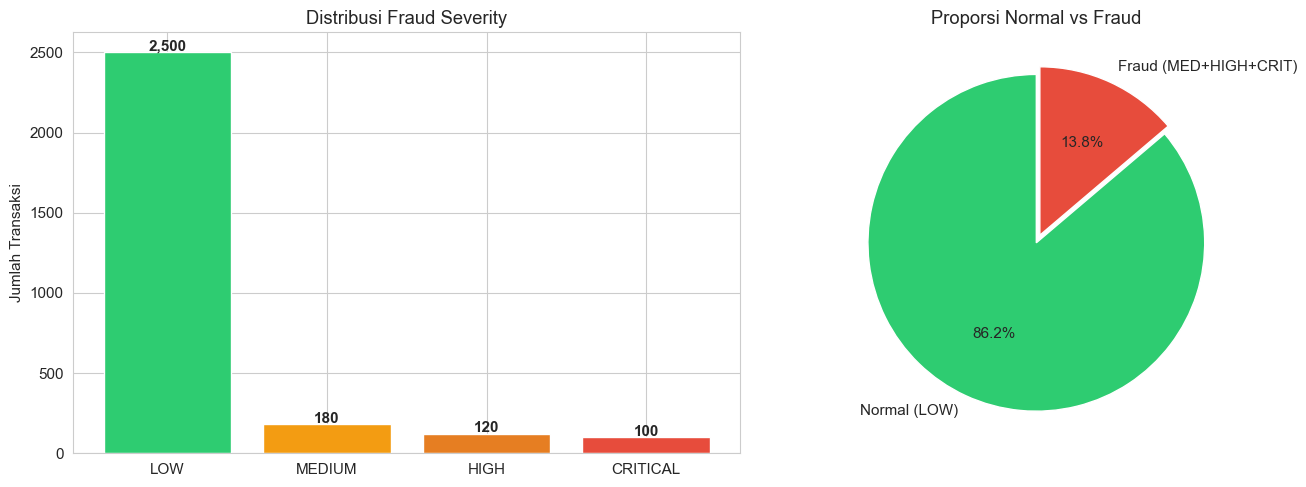

In [25]:
print("[3/5] Visualisasi distribusi data")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: distribusi severity
severity_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
severity_colors = ["#2ecc71", "#f39c12", "#e67e22", "#e74c3c"]

sev_counts = df["fraud_severity"].value_counts().reindex(severity_order)
axes[0].bar(severity_order, sev_counts.values, color=severity_colors, edgecolor="white")
axes[0].set_title("Distribusi Fraud Severity")
axes[0].set_ylabel("Jumlah Transaksi")
for i, v in enumerate(sev_counts.values):
    axes[0].text(i, v + 10, f"{v:,}", ha="center", fontweight="bold")

# Pie chart: proporsi fraud vs normal
fraud_vs_normal = [sev_counts["LOW"], sev_counts[["MEDIUM", "HIGH", "CRITICAL"]].sum()]
axes[1].pie(fraud_vs_normal, labels=["Normal (LOW)", "Fraud (MED+HIGH+CRIT)"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90, explode=(0, 0.05))
axes[1].set_title("Proporsi Normal vs Fraud")

plt.tight_layout()
plt.show()

## Visualisasi: Distribusi Amount per Severity

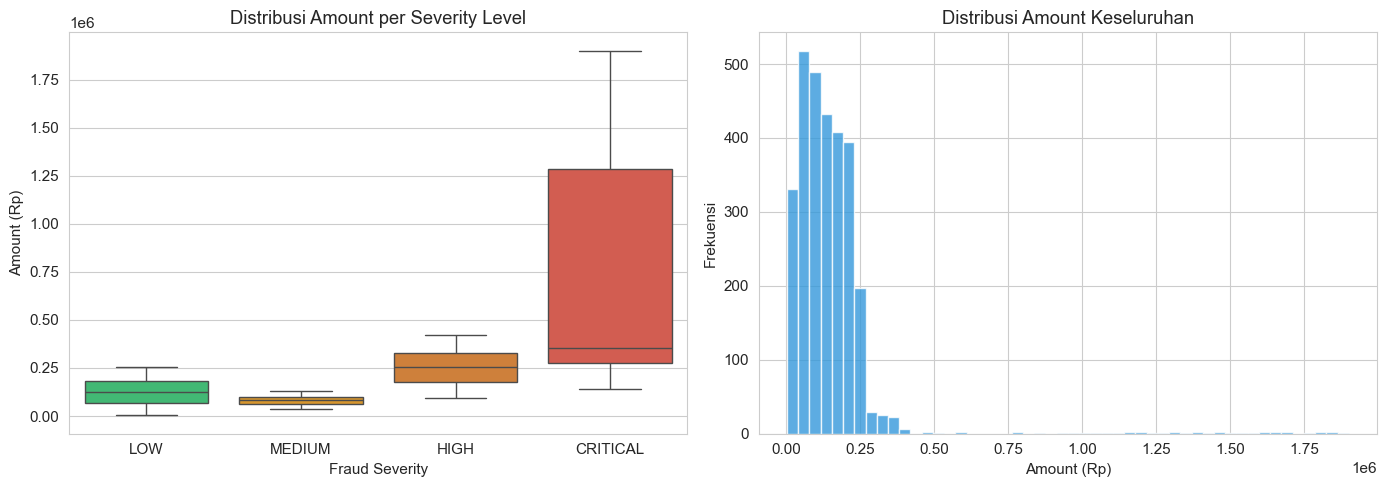

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: amount per severity
sns.boxplot(data=df, x="fraud_severity", y="amount",
            order=severity_order, palette=severity_colors, ax=axes[0])
axes[0].set_title("Distribusi Amount per Severity Level")
axes[0].set_ylabel("Amount (Rp)")
axes[0].set_xlabel("Fraud Severity")

# Histogram: amount keseluruhan
axes[1].hist(df["amount"], bins=50, color="#3498db", edgecolor="white", alpha=0.8)
axes[1].set_title("Distribusi Amount Keseluruhan")
axes[1].set_xlabel("Amount (Rp)")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

## Visualisasi: Pola Waktu & Fraud

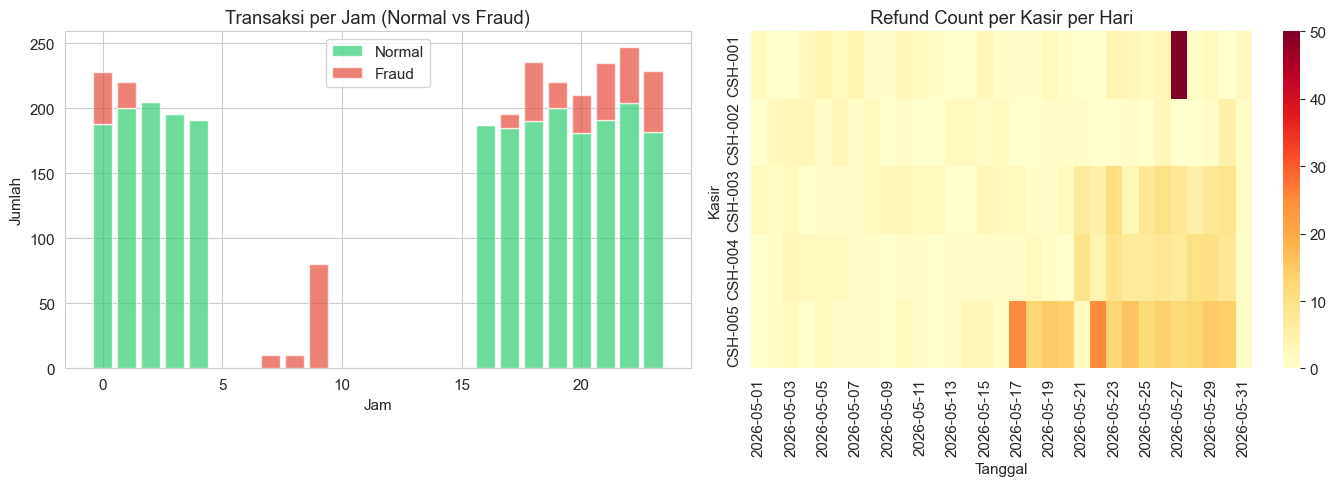

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: transaksi per jam, dibedakan fraud vs normal
df["hour"] = df["timestamp"].dt.hour
hour_normal = df[df["fraud_severity"] == "LOW"]["hour"].value_counts().sort_index()
hour_fraud  = df[df["fraud_severity"] != "LOW"]["hour"].value_counts().sort_index()

# Reindex supaya semua jam 0-23 ada
all_hours = range(24)
hour_normal = hour_normal.reindex(all_hours, fill_value=0)
hour_fraud  = hour_fraud.reindex(all_hours, fill_value=0)

axes[0].bar(all_hours, hour_normal.values, label="Normal", color="#2ecc71", alpha=0.7)
axes[0].bar(all_hours, hour_fraud.values, bottom=hour_normal.values,
            label="Fraud", color="#e74c3c", alpha=0.7)
axes[0].set_title("Transaksi per Jam (Normal vs Fraud)")
axes[0].set_xlabel("Jam")
axes[0].set_ylabel("Jumlah")
axes[0].legend()

# Heatmap: refund count per kasir per hari
df["date"] = df["timestamp"].dt.date
refund_only = df[df["transaction_type"] == "REFUND"]
pivot = refund_only.groupby(["cashier_id", "date"]).size().unstack(fill_value=0)

sns.heatmap(pivot, cmap="YlOrRd", annot=False, ax=axes[1])
axes[1].set_title("Refund Count per Kasir per Hari")
axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Kasir")

plt.tight_layout()
plt.show()

# Bersihkan kolom temporary
df.drop(columns=["hour", "date"], inplace=True)

## Visualisasi: Distribusi Refund per Kasir

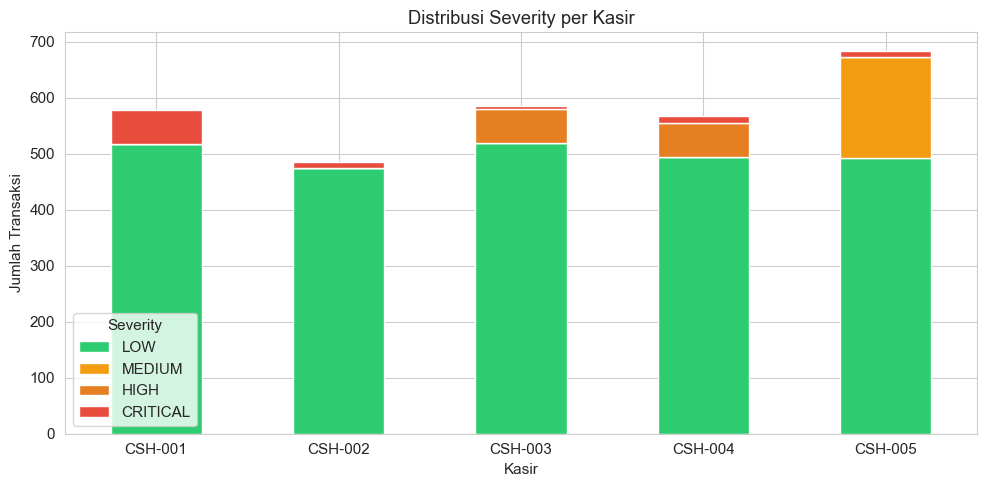

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

# Stacked bar: transaction type per kasir, warnai berdasarkan severity
ct = pd.crosstab(df["cashier_id"], df["fraud_severity"])
ct = ct.reindex(columns=severity_order, fill_value=0)
ct.plot(kind="bar", stacked=True, color=severity_colors, ax=ax, edgecolor="white")

ax.set_title("Distribusi Severity per Kasir")
ax.set_xlabel("Kasir")
ax.set_ylabel("Jumlah Transaksi")
ax.legend(title="Severity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Data Cleaning

In [29]:
print("[4/5] Data Cleaning")

n_before = len(df)

# 1. Hapus duplikat berdasarkan ID
df = df.drop_duplicates(subset=["id"], keep="first")
n_dup_removed = n_before - len(df)
print(f"  Duplikat dihapus: {n_dup_removed}")

# 2. Handle missing values (drop baris yang ada missing)
n_before_na = len(df)
df = df.dropna()
n_na_removed = n_before_na - len(df)
print(f"  Baris missing dihapus: {n_na_removed}")

# 3. Validasi tipe data
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["amount"]    = df["amount"].astype("float64")
print(f"  Tipe data divalidasi")

# 4. Pastikan amount > 0
n_neg = (df["amount"] <= 0).sum()
if n_neg > 0:
    df = df[df["amount"] > 0]
    print(f"  Amount non-positif dihapus: {n_neg}")
else:
    print(f"  Semua amount positif: OK")

# 5. Validasi fraud_severity values
valid_severities = {"LOW", "MEDIUM", "HIGH", "CRITICAL"}
invalid_sev = ~df["fraud_severity"].isin(valid_severities)
if invalid_sev.sum() > 0:
    print(f"  [!] Severity tidak valid ditemukan: {invalid_sev.sum()}")
    df = df[~invalid_sev]
else:
    print(f"  Semua severity valid: OK")

# Sort ulang berdasarkan timestamp
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"\n  Total setelah cleaning: {len(df):,} baris")

[4/5] Data Cleaning
  Duplikat dihapus: 0
  Baris missing dihapus: 0
  Tipe data divalidasi
  Semua amount positif: OK
  Semua severity valid: OK

  Total setelah cleaning: 2,900 baris


## Simpan Data Bersih

In [30]:
print("[5/5] Menyimpan data bersih...")

os.makedirs(OUTPUT_DIR, exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False)

print(f"  Output: {OUTPUT_CSV}")
print(f"  Ukuran: {len(df):,} baris x {df.shape[1]} kolom")
print(f"\n  Distribusi severity akhir:")
for sev in ["LOW", "MEDIUM", "HIGH", "CRITICAL"]:
    cnt = (df["fraud_severity"] == sev).sum()
    print(f"    {sev:10s}: {cnt:,}")

print("\nData bersih siap untuk Tahap 3 (Feature Engineering)")

[5/5] Menyimpan data bersih...
  Output: ..\data\processed\transactions_cleaned.csv
  Ukuran: 2,900 baris x 8 kolom

  Distribusi severity akhir:
    LOW       : 2,500
    MEDIUM    : 180
    HIGH      : 120
    CRITICAL  : 100

Data bersih siap untuk Tahap 3 (Feature Engineering)
